# Imports
initial imports of libraries and modules used in the notebook.

In [150]:
# Standard library
import os

# Third-party — data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Reading

[Link to Dataset](https://www.kaggle.com/datasets/rohitudageri/credit-card-details)

In [151]:
label_df = pd.read_csv('./Credit_card_label.csv')
data_df = pd.read_csv('./Credit_card.csv')

# concat the two dataframes where the Ind_ID is the same
df = pd.merge(data_df, label_df, on='Ind_ID')
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [153]:
df.duplicated().sum()

np.int64(0)

To ensure, drop the duplicates from the dataset and check the number of duplicates that were removed.

In [154]:
df.drop_duplicates(inplace=True)

In [155]:
df.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')

To ensure consistency, lowercase all the columns and strip the whitespaces on the columns

In [156]:
# lower case all the columns
df.columns = df.columns.str.lower()

# strip the columns of whitespace
df.columns = df.columns.str.strip()

df.columns

Index(['ind_id', 'gender', 'car_owner', 'propert_owner', 'children',
       'annual_income', 'type_income', 'education', 'marital_status',
       'housing_type', 'birthday_count', 'employed_days', 'mobile_phone',
       'work_phone', 'phone', 'email_id', 'type_occupation', 'family_members',
       'label'],
      dtype='object')

In [157]:
df.describe()

,ind_id,children,annual_income,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,family_members,label
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


In [158]:
# Drop the id. It is not relevant to the analysis and can be used to identify individuals in the dataset.
df.drop(columns=['ind_id'], inplace=True)

# Also drop the mobile_phone column as all the values are the same and it is not relevant to the analysis.
df.drop(columns=['mobile_phone'], inplace=True)

df.head()

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,type_occupation,family_members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,0,0,0,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,0,NaN,2,1
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1


In [159]:
df.isnull().sum()

gender               7
car_owner            0
propert_owner        0
children             0
annual_income       23
type_income          0
education            0
marital_status       0
housing_type         0
birthday_count      22
employed_days        0
work_phone           0
phone                0
email_id             0
type_occupation    488
family_members       0
label                0
dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1541 non-null   object 
 1   car_owner        1548 non-null   object 
 2   propert_owner    1548 non-null   object 
 3   children         1548 non-null   int64  
 4   annual_income    1525 non-null   float64
 5   type_income      1548 non-null   object 
 6   education        1548 non-null   object 
 7   marital_status   1548 non-null   object 
 8   housing_type     1548 non-null   object 
 9   birthday_count   1526 non-null   float64
 10  employed_days    1548 non-null   int64  
 11  work_phone       1548 non-null   int64  
 12  phone            1548 non-null   int64  
 13  email_id         1548 non-null   int64  
 14  type_occupation  1060 non-null   object 
 15  family_members   1548 non-null   int64  
 16  label            1548 non-null   int64  
dtypes: float64(2),

The DTypes are correct. But there are some missing values in the `gender`, `annual_income`, `birthday_count` and the `employed_days` column.

First, Remove the type_occupation column as it has a lot of missing values

In [161]:
df.drop(columns=['type_occupation'], inplace=True)

Use an Imputer for the rest of the columns

In [162]:
from sklearn.impute import SimpleImputer

In [163]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

# create an imputer for the categorical columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
# create an imputer for the numerical columns
numerical_imputer = SimpleImputer(strategy='median')

# fit the imputer on the categorical columns
for col in categorical_cols:
    df[col] = categorical_imputer.fit_transform(df[[col]]).ravel()

# fit the imputer on the numerical columns
for col in numerical_cols:
    df[col] = numerical_imputer.fit_transform(df[[col]]).ravel()

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          1548 non-null   object 
 1   car_owner       1548 non-null   object 
 2   propert_owner   1548 non-null   object 
 3   children        1548 non-null   float64
 4   annual_income   1548 non-null   float64
 5   type_income     1548 non-null   object 
 6   education       1548 non-null   object 
 7   marital_status  1548 non-null   object 
 8   housing_type    1548 non-null   object 
 9   birthday_count  1548 non-null   float64
 10  employed_days   1548 non-null   float64
 11  work_phone      1548 non-null   float64
 12  phone           1548 non-null   float64
 13  email_id        1548 non-null   float64
 14  family_members  1548 non-null   float64
 15  label           1548 non-null   float64
dtypes: float64(9), object(7)
memory usage: 193.6+ KB


In [165]:
df.isna().sum()

gender            0
car_owner         0
propert_owner     0
children          0
annual_income     0
type_income       0
education         0
marital_status    0
housing_type      0
birthday_count    0
employed_days     0
work_phone        0
phone             0
email_id          0
family_members    0
label             0
dtype: int64

As seen in the data, there seems to have a value under `employed_days` that occurs multiple times. The value is 365243.

In [166]:
# Get the rows with the value 365243 in the employed_days column
df[df['employed_days'] == 365243].count()

gender            261
car_owner         261
propert_owner     261
children          261
annual_income     261
type_income       261
education         261
marital_status    261
housing_type      261
birthday_count    261
employed_days     261
work_phone        261
phone             261
email_id          261
family_members    261
label             261
dtype: int64

There are 261 rows with the value 365243 in the employed_days column.

Let's transform the value 365243 in the employed_days column to NaN for now

In [167]:
# Transform these values to NaN as they are likely to be outliers or errors in the data.
# additionally we can use these later for feature engineering to create a new feature
# that indicates whether they are employed or not.
df["employed_days"] = df["employed_days"].replace(365243, np.nan)

In [168]:
df.head()

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,family_members,label
0,M,Y,Y,0.0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,NaN,0.0,0.0,0.0,2.0,1.0
1,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0
2,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,-586.0,1.0,1.0,0.0,2.0,1.0
3,F,Y,N,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0
4,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0


Ensure that there are no more missing values in the dataset and that the DTypes are correct.

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          1548 non-null   object 
 1   car_owner       1548 non-null   object 
 2   propert_owner   1548 non-null   object 
 3   children        1548 non-null   float64
 4   annual_income   1548 non-null   float64
 5   type_income     1548 non-null   object 
 6   education       1548 non-null   object 
 7   marital_status  1548 non-null   object 
 8   housing_type    1548 non-null   object 
 9   birthday_count  1548 non-null   float64
 10  employed_days   1287 non-null   float64
 11  work_phone      1548 non-null   float64
 12  phone           1548 non-null   float64
 13  email_id        1548 non-null   float64
 14  family_members  1548 non-null   float64
 15  label           1548 non-null   float64
dtypes: float64(9), object(7)
memory usage: 193.6+ KB


# EDA

Since `phone`, `work_phone`, `email_id` has 0 or 1 values, transform these columns to boolean values where 0 is False and 1 is True for the sake of EDA.

In [170]:
eda_df = df.copy()

eda_df["phone"] = eda_df["phone"].astype(bool)
eda_df["work_phone"] = eda_df["work_phone"].astype(bool)
eda_df["email_id"] = eda_df["email_id"].astype(bool)

Define the numerical and categorical columns

In [171]:
eda_numerical_cols = eda_df.select_dtypes(include=['number']).columns
eda_categorical_cols = eda_df.select_dtypes(include=['bool', 'object']).columns

In [172]:
eda_df.describe()

,children,annual_income,birthday_count,employed_days,family_members,label
count,1548.000000,1.548000e+03,1548.000000,1287.000000,1548.000000,1548.000000
mean,0.412791,1.910294e+05,-16034.958010,-2666.575758,2.161499,0.113049
std,0.776691,1.124483e+05,4199.561035,2397.536850,0.947772,0.316755
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.000000,0.000000
25%,0.000000,1.215000e+05,-19476.000000,-3505.500000,2.000000,0.000000
50%,0.000000,1.665000e+05,-15661.500000,-1953.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12483.000000,-931.500000,3.000000,0.000000
max,14.000000,1.575000e+06,-7705.000000,-73.000000,15.000000,1.000000


In [173]:
# helper function to interpret level of skewness
def interpret_skewness(skew_value):
    if skew_value > 1:
        return "highly positively skewed"
    elif skew_value > 0.5:
        return "moderately positively skewed"
    elif skew_value > 0:
        return "slightly positively skewed"
    elif skew_value < -1:
        return "highly negatively skewed"
    elif skew_value < -0.5:
        return "moderately negatively skewed"
    elif skew_value < 0:
        return "slightly negatively skewed"
    else:
        return "symmetrical distribution"

In [174]:
# Get the skewness of the numerical columns
skewness = df[eda_numerical_cols].skew()

skewness_interpretation = skewness.apply(interpret_skewness)

print("Skewness of numerical columns:")
print(skewness)
print("\nInterpretation of skewness:")
print(skewness_interpretation)

Skewness of numerical columns:
children          4.631122
annual_income     3.959453
birthday_count   -0.176124
employed_days    -1.687212
family_members    2.232273
label             2.446379
dtype: float64

Interpretation of skewness:
children            highly positively skewed
annual_income       highly positively skewed
birthday_count    slightly negatively skewed
employed_days       highly negatively skewed
family_members      highly positively skewed
label               highly positively skewed
dtype: object


We can see that most of the columns has a a highly positively skewed distribution. This is expected as most of the customers will have a low credit limit and a low balance. However, there are some customers who have a high credit limit and a high balance, which is why we see a long tail in the distribution.

Decision: Basing on the results of the skewness, avoid using log transformations. Instead, Use plot types based on feature behavior for clearer EDA.

- Evaluate first the target variable distribution to understand the class imbalance and choose appropriate evaluation metrics for modeling.
- Use a violinplot for each of the numerical columns to see the differences in medians, quartiles, and outliers between the classes

Exception: The `annual_income` can be log transformed to reduce the skewness and make the distribution more normal. This can help improve the performance of some machine learning algorithms that assume normality. However, it is important to note that log transformation can also make the interpretation of the data more difficult, as the values will be in a different scale. Therefore, it is important to carefully consider whether log transformation is appropriate for the `annual_income` column before applying it.

In [175]:
target_col = "label"

Evaluate the target variable

<Axes: xlabel='label', ylabel='count'>

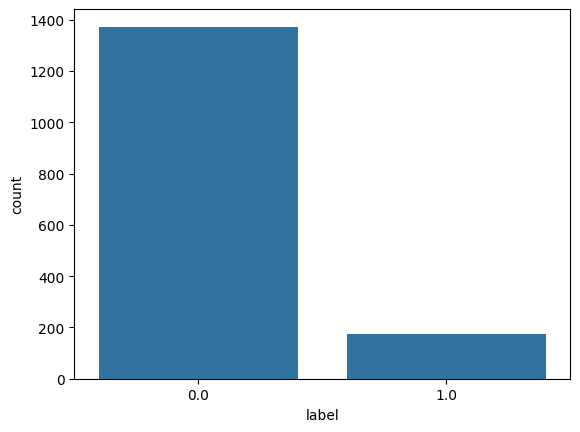

In [176]:
sns.barplot(df[target_col].value_counts())

Label target has a significant difference. There are a lot of 0 target values and low amount of 1 values. Use either using SMOTE or some other techniques that will help equal the number of data for the model to learn.

Check the violinplots for the numerical columns

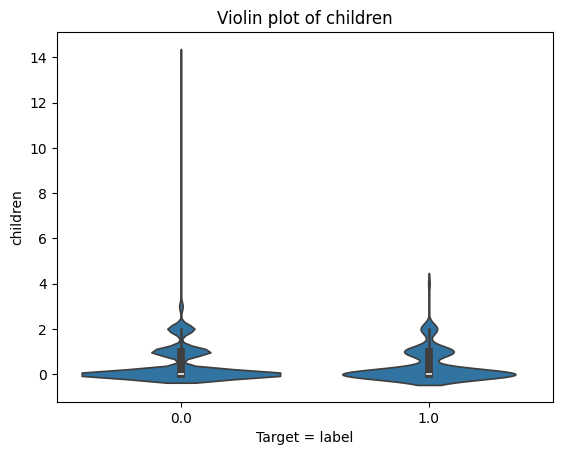

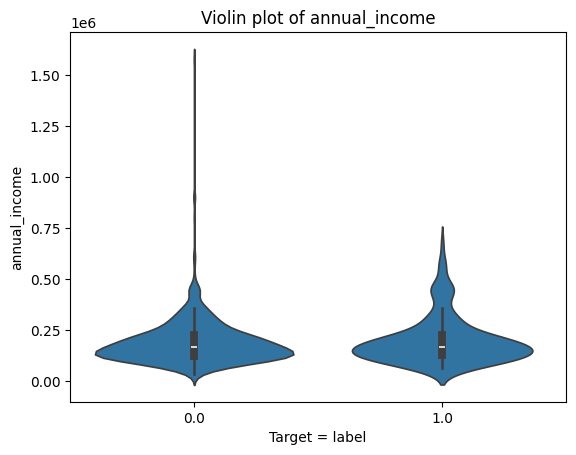

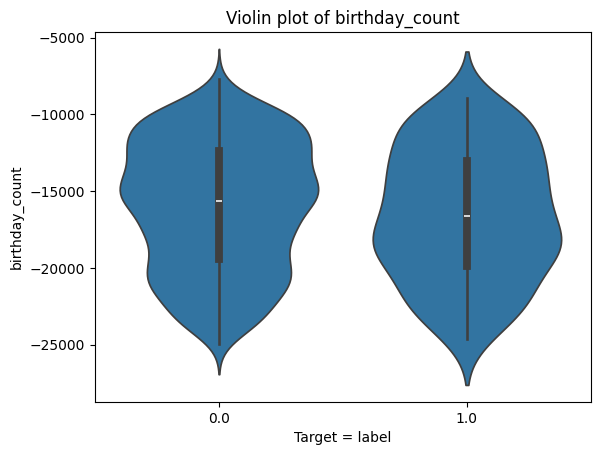

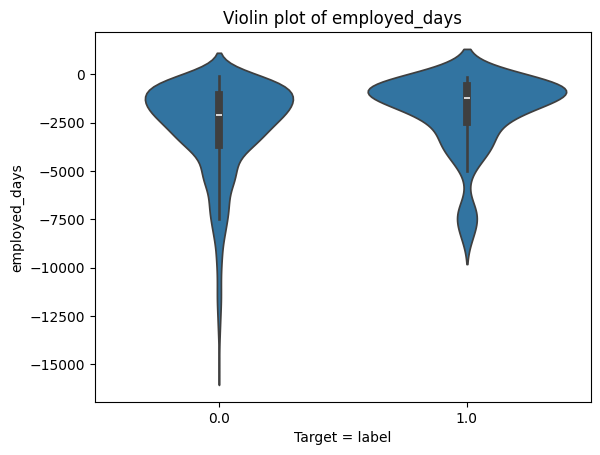

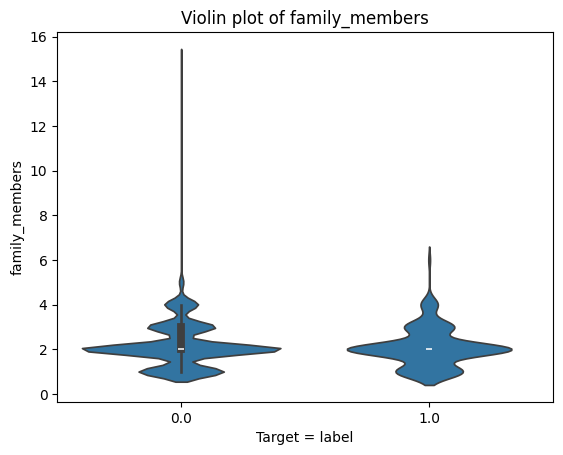

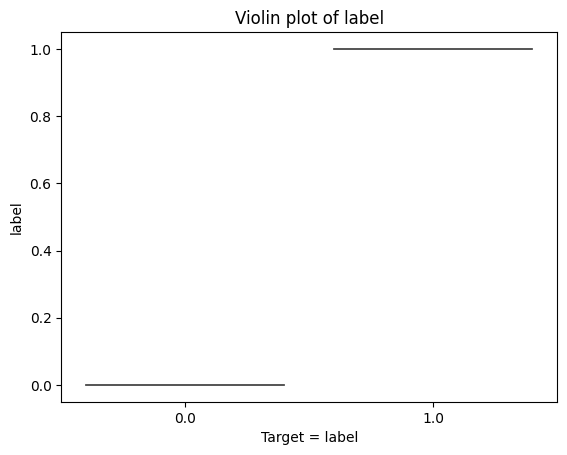

In [177]:
for col in eda_numerical_cols:
    sns.violinplot(y=col, data=eda_df, x=target_col)
    plt.title(f'Violin plot of {col}')
    plt.xlabel('Target = label')
    plt.ylabel(col)
    plt.show()


Most of the numerical features show strong overlap between the two classes, indicating that they may not be strong predictors on their own. However, there are some features that show some separation between the classes, which could be useful for modeling. It may be beneficial to explore feature engineering or interaction terms to improve the predictive power of the model.

In [178]:
# Log transform the annual_income column to reduce the skewness
df['annual_income_logged'] = np.log(df['annual_income'] + 1)
eda_df['annual_income_logged'] = np.log(eda_df['annual_income'] + 1)

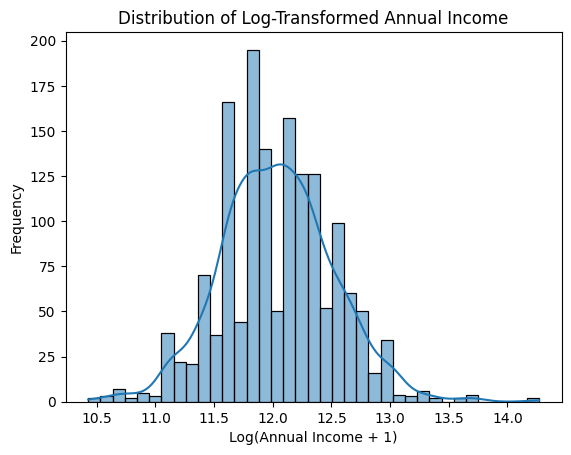

In [179]:
sns.histplot(eda_df['annual_income_logged'], kde=True)
plt.title('Distribution of Log-Transformed Annual Income')
plt.xlabel('Log(Annual Income + 1)')
plt.ylabel('Frequency')
plt.show()

Now let's look at the categorical features

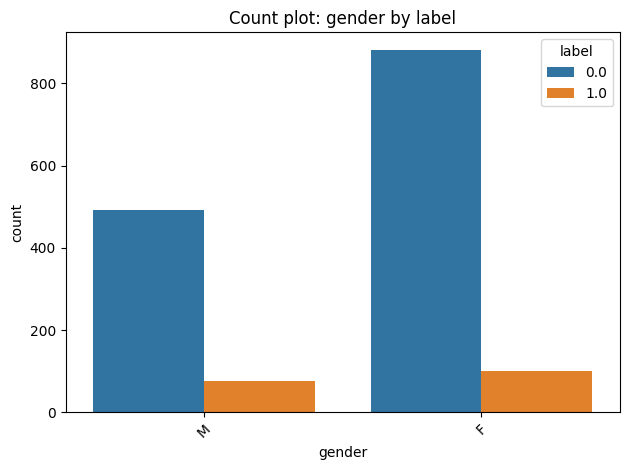

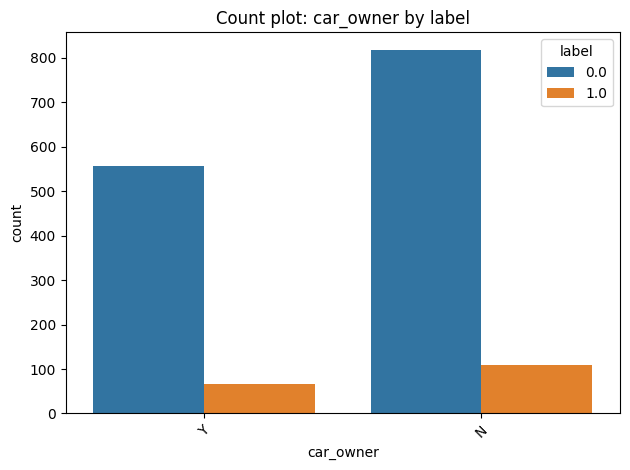

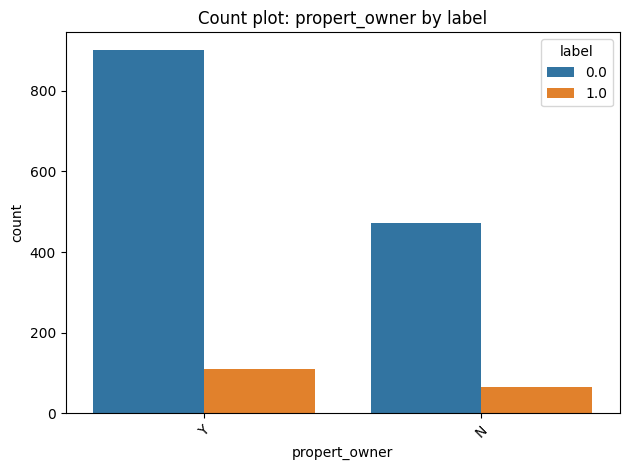

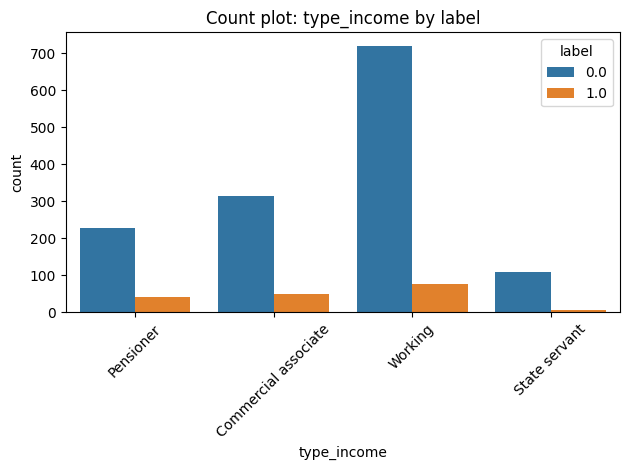

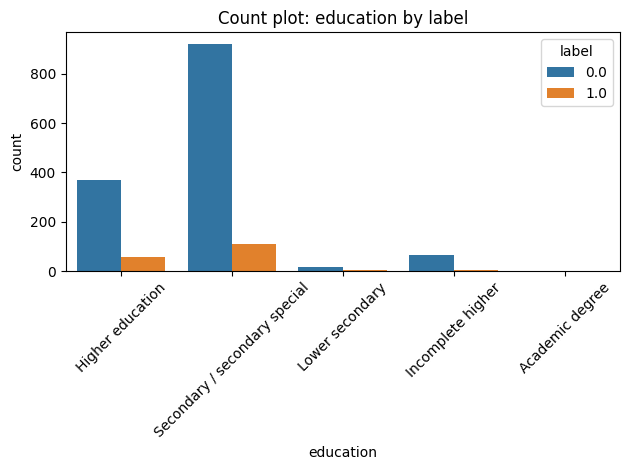

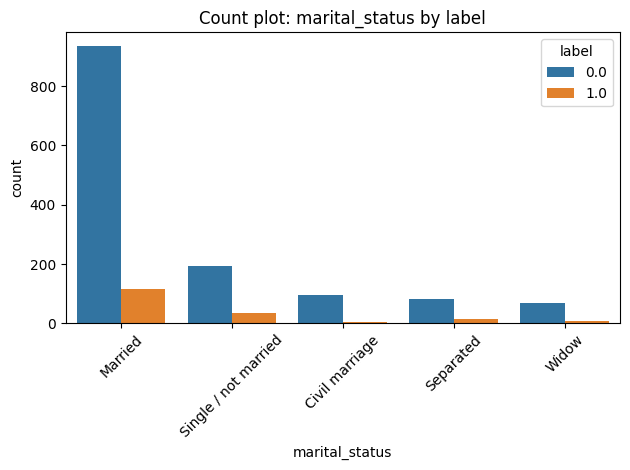

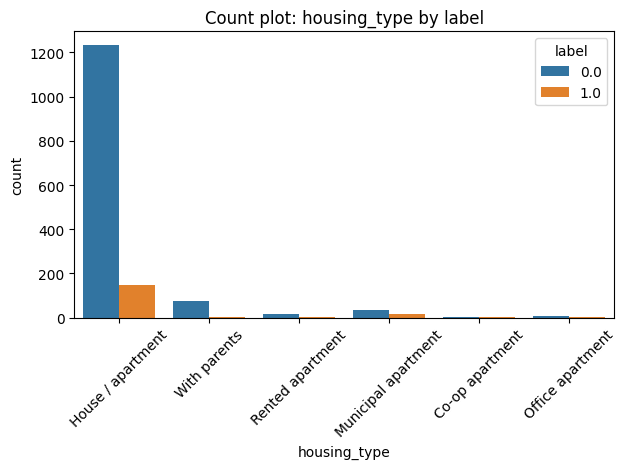

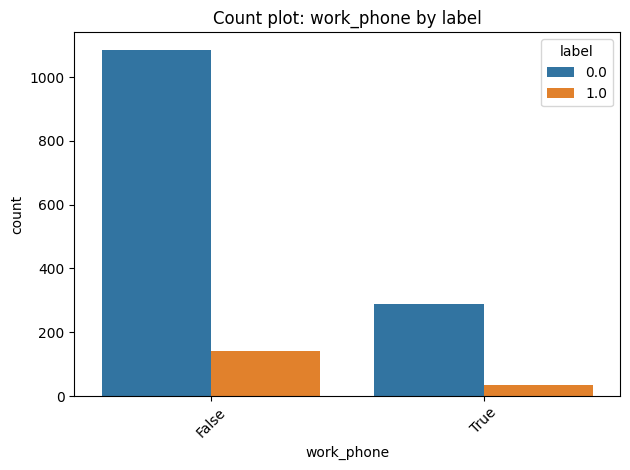

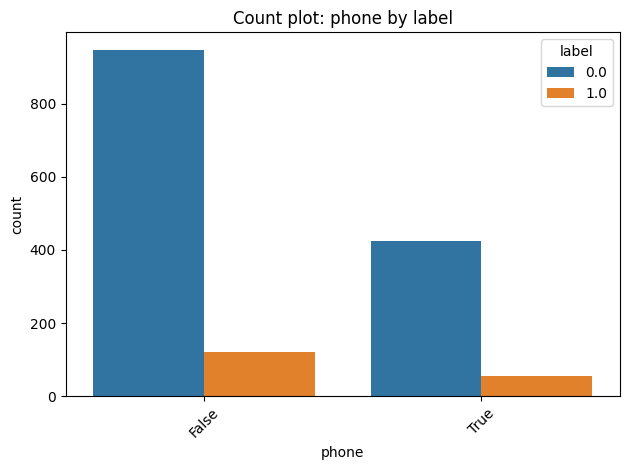

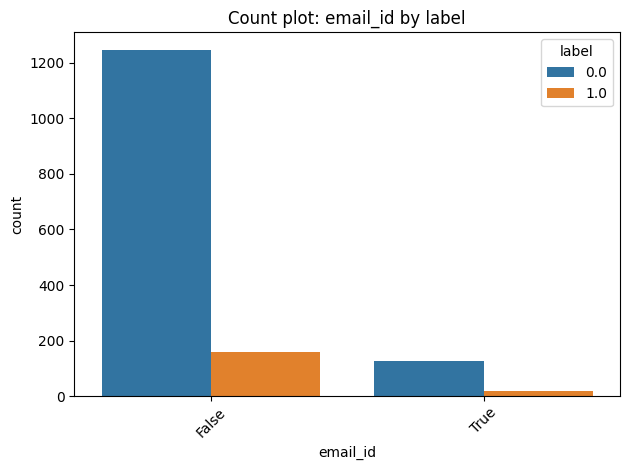

In [180]:
for col in eda_categorical_cols:

    # A) Count by category + class
    sns.countplot(data=eda_df, x=col, hue=target_col)
    plt.title(f"Count plot: {col} by label")
    plt.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

Some categorical columns such as `type_income`, `marital_status`, and `housing_type` shows visible variation. While other categorical columns shows no visible variation. This may indicate that the former categorical columns may be more useful for modeling than the latter categorical columns.

It is also important to note of the `employed_days` column as it has a lot of missing values and a lot of values that are 365243. In the setup, these values are changed to NaN but is not imputed. This may be a problem as the model will not be able to learn from these values. It may be beneficial to impute these values with the median or mean of the column to ensure that the model can learn from these values.

Strategy: Need to flag which rows has `employed_days` values that are 365243 to ensure that the model can learn from these values. Preferrably, change the value to a more meaningful value such as the median or mean of the column.

Additional Info: based on the data set, any employed_days value that is positive would be equivalent to the person not being employed. We can use this info to create an unemployed column that will flag the rows with employed_days values that are 365243 as 1 and the rest as 0. This way, the model can learn from the fact that these rows are unemployed without having to impute the values in the employed_days column.

# Feature Engineering

In [181]:
# create a new column for identifying whether the person is unemployed or not based on the employed_days column. If the value is NaN, then it is likely that the person is unemployed.
df["unemployed"] = df["employed_days"].isna().astype(int)

# Use the median to impute the missing values in the employed_days column as it is less affected by outliers than the mean.
df["employed_days"].fillna(df["employed_days"].median(), inplace=True)

In [182]:
df.columns

Index(['gender', 'car_owner', 'propert_owner', 'children', 'annual_income',
       'type_income', 'education', 'marital_status', 'housing_type',
       'birthday_count', 'employed_days', 'work_phone', 'phone', 'email_id',
       'family_members', 'label', 'annual_income_logged', 'unemployed'],
      dtype='object')

In [183]:
df

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,family_members,label,annual_income_logged,unemployed
0,M,Y,Y,0.0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,-1953.0,0.0,0.0,0.0,2.0,1.0,12.100718,1
1,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
2,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
3,F,Y,N,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.022757,0
4,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,F,N,Y,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182.0,0.0,0.0,0.0,2.0,0.0,12.022757,0
1544,F,N,N,0.0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209.0,0.0,0.0,0.0,1.0,0.0,12.323860,0
1545,M,Y,Y,2.0,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477.0,0.0,0.0,0.0,4.0,0.0,12.100718,0
1546,M,Y,N,0.0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645.0,1.0,1.0,0.0,2.0,0.0,12.506181,0


# Encoding

In [184]:
# Binary encoding
binary_cols = ['gender', 'car_owner', 'propert_owner', 'work_phone', 'phone', 'email_id', 'unemployed']
one_hot_cols = ['type_income', 'education', 'marital_status', 'housing_type']

In [185]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [186]:
encoded_df = df.copy()

le = LabelEncoder()

# Gender
encoded_df["gender"] = encoded_df['gender'].map({'M': 1, 'F': 0})

for col in binary_cols:
    encoded_df[col] = le.fit_transform(encoded_df[col])

ohe = OneHotEncoder(sparse_output=False)

for col in one_hot_cols:
    transformed = ohe.fit_transform(encoded_df[[col]])
    ohe_df = pd.DataFrame(transformed, columns=ohe.get_feature_names_out([col]))
    encoded_df = pd.concat([encoded_df, ohe_df], axis=1)
    encoded_df.drop(columns=col)

encoded_df

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,...,marital_status_Married,marital_status_Separated,marital_status_Single / not married,marital_status_Widow,housing_type_Co-op apartment,housing_type_House / apartment,housing_type_Municipal apartment,housing_type_Office apartment,housing_type_Rented apartment,housing_type_With parents
0,1,1,1,0.0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,1,0,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,1,0,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0,1,0,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,1,0,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,0,0,1,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-11957.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1544,0,0,0,0.0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1545,1,1,1,2.0,180000.0,Working,Higher education,Married,House / apartment,-13174.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1546,1,1,0,0.0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
